In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

import tensorflow as tf
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = \
    tf.keras.datasets.imdb.load_data(num_words=10000)

print(f"Train samples : {len(X_train_raw)}")
print(f"Test samples  : {len(X_test_raw)}")
print(f"Sample review : {X_train_raw[0][:15]}...")
print(f"Label         : {y_train_raw[0]}")
print(f"Review lengths: min={min(len(x) for x in X_train_raw)}, "
      f"max={max(len(x) for x in X_train_raw)}, "
      f"mean={np.mean([len(x) for x in X_train_raw]):.0f}")

Device: cuda


2026-05-26 08:10:12.927908: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779783013.141188      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779783013.203900      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779783013.701056      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779783013.701132      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779783013.701136      57 computation_placer.cc:177] computation placer alr

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train samples : 25000
Test samples  : 25000
Sample review : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4]...
Label         : 1
Review lengths: min=11, max=2494, mean=239


Positive reviews: 12500 (50.0%)
Negative reviews: 12500 (50.0%)


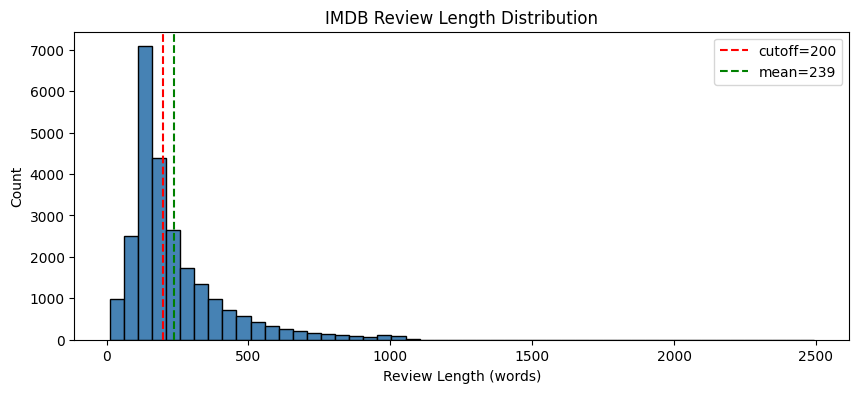


Reviews under 200 words: 57.3%
Reviews under 500 words: 91.6%


In [ ]:
print(f"Positive reviews: {y_train_raw.sum()} ({y_train_raw.mean()*100:.1f}%)")
print(f"Negative reviews: {(1-y_train_raw).sum()} ({(1-y_train_raw).mean()*100:.1f}%)")

lengths = [len(x) for x in X_train_raw]
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black')
plt.axvline(x=200, color='red', linestyle='--', label='cutoff=200')
plt.axvline(x=np.mean(lengths), color='green', linestyle='--', 
            label=f'mean={np.mean(lengths):.0f}')
plt.xlabel('Review Length (words)')
plt.ylabel('Count')
plt.title('IMDB Review Length Distribution')
plt.legend()
plt.show()

print(f"\nReviews under 200 words: {sum(l<=200 for l in lengths)/len(lengths)*100:.1f}%")
print(f"Reviews under 500 words: {sum(l<=500 for l in lengths)/len(lengths)*100:.1f}%")

In [ ]:
MAX_LEN = 500
VOCAB_SIZE = 10000 

def pad_or_truncate(sequence, max_len):
    if len(sequence) > max_len:
        return sequence[:max_len]   
    else:
        return [0] * (max_len - len(sequence)) + sequence  

# Test it
sample = X_train_raw[0]
print(f"Original length : {len(sample)}")
processed = pad_or_truncate(sample, MAX_LEN)
print(f"After processing: {len(processed)}")
print(f"First 10 tokens : {processed[:10]}") 

Original length : 218
After processing: 500
First 10 tokens : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, X, y, max_len):
        self.X = [pad_or_truncate(x, max_len) for x in X]
        self.y = y
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return (torch.tensor(self.X[idx], dtype=torch.long),
                torch.tensor(self.y[idx], dtype=torch.float))

train_dataset = IMDBDataset(X_train_raw, y_train_raw, MAX_LEN)
test_dataset  = IMDBDataset(X_test_raw,  y_test_raw,  MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

X_batch, y_batch = next(iter(train_loader))
print(f"X_batch shape: {X_batch.shape}") 
print(f"y_batch shape: {y_batch.shape}")  
print(f"X dtype: {X_batch.dtype}")        
print(f"y dtype: {y_batch.dtype}")  

X_batch shape: torch.Size([64, 500])
y_batch shape: torch.Size([64])
X dtype: torch.int64
y dtype: torch.float32


In [ ]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers):
        super(VanillaRNN, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
       
        self.rnn = nn.RNN(
            input_size  = embed_dim,   
            hidden_size = hidden_dim, 
            num_layers  = n_layers,    
            batch_first = True,        
            dropout     = 0.3 if n_layers > 1 else 0
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, 1)  
        )
    
    def forward(self, x):
        
        embedded = self.embedding(x)

        output, hidden = self.rnn(embedded)
        hidden = hidden[-1] 
        
        return self.classifier(hidden).squeeze(1)


class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers):
        super(SentimentLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = n_layers,
            batch_first = True,
            dropout     = 0.3 if n_layers > 1 else 0
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x):
        embedded = self.embedding(x)
        
        output, (hidden, cell) = self.lstm(embedded)

        
        hidden = hidden[-1]  
        
        return self.classifier(hidden).squeeze(1)


class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers):
        super(BiLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            input_size   = embed_dim,
            hidden_size  = hidden_dim,
            num_layers   = n_layers,
            batch_first  = True,
            dropout      = 0.3 if n_layers > 1 else 0,
            bidirectional= True  
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim * 2, 1) 
        )
    
    def forward(self, x):
        embedded = self.embedding(x)
        
        output, (hidden, cell) = self.lstm(embedded)
   
        hidden_fwd = hidden[-2] 
        hidden_bwd = hidden[-1] 
        hidden     = torch.cat([hidden_fwd, hidden_bwd], dim=1)
        
        return self.classifier(hidden).squeeze(1)


VOCAB_SIZE = 10000
EMBED_DIM  = 128   
HIDDEN_DIM = 256   
N_LAYERS   = 2   

rnn_model  = VanillaRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS).to(device)
lstm_model = SentimentLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS).to(device)
bilstm_model = BiLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS).to(device)

for name, model in [('RNN', rnn_model), ('LSTM', lstm_model), ('BiLSTM', bilstm_model)]:
    params = sum(p.numel() for p in model.parameters())
    print(f"{name:10} parameters: {params:,}")

RNN        parameters: 1,510,657
LSTM       parameters: 2,201,857
BiLSTM     parameters: 3,648,001


In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch).squeeze()
        loss        = criterion(predictions, y_batch)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        predicted   = (torch.sigmoid(predictions) >= 0.5).float()
        correct    += (predicted == y_batch).sum().item()
        total      += y_batch.size(0)
    
    return total_loss / len(loader), 100 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            predictions = model(X_batch).squeeze()
            loss        = criterion(predictions, y_batch)
            
            total_loss += loss.item()
            predicted   = (torch.sigmoid(predictions) >= 0.5).float()
            correct    += (predicted == y_batch).sum().item()
            total      += y_batch.size(0)
    
    return total_loss / len(loader), 100 * correct / total

In [ ]:
def train_model(model, model_name, n_epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=2, factor=0.5)
    
    best_val_acc     = 0.0
    patience         = 3
    patience_counter = 0
    
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")
    
    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, 
                                             criterion, optimizer, device)
        val_loss, val_acc     = evaluate(model, test_loader, 
                                          criterion, device)
        scheduler.step(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc     = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f'best_{model_name}.pth')
        else:
            patience_counter += 1
        
        print(f"Epoch {epoch+1:2d}/{n_epochs} | "
              f"Train: {train_acc:.1f}% | "
              f"Val: {val_acc:.1f}% | "
              f"Patience: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    model.load_state_dict(torch.load(f'best_{model_name}.pth'))
    print(f"\n{model_name} Best Val Accuracy: {best_val_acc:.2f}%")
    return best_val_acc


criterion = nn.BCEWithLogitsLoss()

rnn_acc    = train_model(rnn_model,   'RNN',    n_epochs=10)
lstm_acc   = train_model(lstm_model,  'LSTM',   n_epochs=10)
bilstm_acc = train_model(bilstm_model,'BiLSTM', n_epochs=10)

print(f"\n{'='*40}")
print(f"FINAL COMPARISON")
print(f"{'='*40}")
print(f"Vanilla RNN : {rnn_acc:.2f}%")
print(f"LSTM        : {lstm_acc:.2f}%")
print(f"BiLSTM      : {bilstm_acc:.2f}%")


Training RNN
Epoch  1/10 | Train: 58.2% | Val: 56.8% | Patience: 0/3
Epoch  2/10 | Train: 59.3% | Val: 70.3% | Patience: 0/3
Epoch  3/10 | Train: 60.3% | Val: 72.6% | Patience: 0/3
Epoch  4/10 | Train: 73.8% | Val: 75.2% | Patience: 0/3
Epoch  5/10 | Train: 77.2% | Val: 76.9% | Patience: 0/3
Epoch  6/10 | Train: 77.4% | Val: 74.7% | Patience: 1/3
Epoch  7/10 | Train: 81.8% | Val: 76.0% | Patience: 2/3
Epoch  8/10 | Train: 81.6% | Val: 72.9% | Patience: 3/3
Early stopping at epoch 8

RNN Best Val Accuracy: 76.92%

Training LSTM
Epoch  1/10 | Train: 64.7% | Val: 75.1% | Patience: 0/3
Epoch  2/10 | Train: 80.4% | Val: 83.8% | Patience: 0/3
Epoch  3/10 | Train: 86.3% | Val: 85.6% | Patience: 0/3
Epoch  4/10 | Train: 88.8% | Val: 87.2% | Patience: 0/3
Epoch  5/10 | Train: 91.6% | Val: 88.1% | Patience: 0/3
Epoch  6/10 | Train: 93.5% | Val: 87.8% | Patience: 1/3
Epoch  7/10 | Train: 95.4% | Val: 87.7% | Patience: 2/3
Epoch  8/10 | Train: 96.8% | Val: 86.1% | Patience: 3/3
Early stopping at 